# Task 5 — Held-out Dose Prediction and Predictive Perturbation Modeling

**核心问题：如果某个 drug × dose condition 没被实验测量，能否根据其它已观察条件预测它的转录状态？**

这是把整个项目从「**观测**（observed perturbation）」推向「**预测**（predictive perturbation）」的一步。

⚠️ **准确性声明（贯穿全篇）**：本 notebook 做的是 **held-out pharmacological response prediction**，不是「开发了 Virtual Cell」。真正的 Virtual Cell 还需要 unseen drug / unseen context / 多模态 / 时间动态 / 实验闭环，这些都不在本次范围。


## 1. 读取数据 + 核对 metadata

### What are we doing?
读取 Task 3 的对象，确认 PCA、raw counts、metadata 位置。


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge

DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("results") / "task5"; RES_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.set_figure_params(dpi=100, dpi_save=300, frameon=False)

adata = sc.read_h5ad(DATA_DIR / "processed" / "adata_perturbation_landscape.h5ad")
adata


AnnData object with n_obs × n_vars = 23628 × 58347
    obs: 'ncounts', 'hash_umis', 'pval_demultiplexing', 'qval_demultiplexing', 'top_to_second_best_ratio', 'top_oligo', 'perturbation', 'dose_value', 'well', 'celltype', 'cell_line', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'rep_idx', 'is_treated', 'leiden'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dose_value_colors', 'hvg', 'is_treated_colors', 'leiden', 'leiden_colors', 'log1p', 'n

In [3]:
adata.shape, list(adata.obsm.keys()), list(adata.layers.keys())


((23628, 58347), ['X_pca', 'X_umap'], ['counts'])

In [4]:
adata.obs.columns.tolist()


['ncounts',
 'hash_umis',
 'pval_demultiplexing',
 'qval_demultiplexing',
 'top_to_second_best_ratio',
 'top_oligo',
 'perturbation',
 'dose_value',
 'well',
 'celltype',
 'cell_line',
 'cancer',
 'disease',
 'tissue_type',
 'organism',
 'perturbation_type',
 'ngenes',
 'percent_mito',
 'percent_ribo',
 'nperts',
 'chembl-ID',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'total_counts_mt',
 'log1p_total_counts_mt',
 'pct_counts_mt',
 'rep_idx',
 'is_treated',
 'leiden']

### What does the output mean?

- **drug**：`obs['perturbation']`；**dose**：`obs['dose_value']`；**replicate**：`obs['well']`
- **vehicle**：`dose_value == 0`（hashtag 处理的溶剂对照）
- **PCA**：`obsm['X_pca']`（50 维）；**raw counts**：`layers['counts']`；**normalized**：`.X`
- **Task 4 结果**：`results/task4/*.csv`


## 2. Dose 转数值 + 实验设计

### Why does it matter?
剂量必须按真实数值排序（0.1 < 1 < 10 < 100），不能按字符串字典序（会变成 '0.1','1','10','100','5','50'）。


In [5]:
DOSE_LIST = ['0', '0.1', '0.5', '1', '5', '10', '50', '100']
adata.obs['dose_num'] = pd.to_numeric(adata.obs['dose_value'].astype(str), errors='coerce')

cnt = adata.obs.groupby(['perturbation', 'dose_value'], observed=True).size().unstack(fill_value=0)
print("细胞数表（Nutlin/SAHA/vehicle）:")
cnt


细胞数表（Nutlin/SAHA/vehicle）:


dose_value,0,0.1,0.5,1,5,10,50,100
perturbation,,,,,,,,
BMS,959,902,703,506,435,292,137,126
Dex,886,897,824,1031,992,882,1115,1257
Nutlin,976,833,768,874,811,1069,395,80
SAHA,983,767,692,639,518,523,717,518


## 3. Held-out 设计与数据泄漏（最高优先级）

### 什么是 held-out dose？
把一个 `drug × dose` 条件**完整隐藏**，训练时完全看不到它，再用模型预测它。

### 什么是数据泄漏？
如果 held-out dose 的细胞在训练阶段参与了 **PCA fitting / scaler / 模型训练 / 特征选择 / 超参选择**，那么模型在测试时已经"见过"这些信息，evaluation 会**过度乐观**——你以为预测得好，其实是作弊。

### 本 notebook 如何防泄漏？
- PCA 是**预先在全部数据上算好的**（Task 3 产物），我们**不改动它**——因为我们的预测目标是「PCA 状态」，而 PCA 是固定的坐标系统，不是从 held-out 学来的。严格说，理想做法应该只在训练数据上重算 PCA；这里用全量 PCA 是为了与 Task 3/4 一致，且 PCA 本身不"知道"哪个 dose 被隐藏。
- **关键防线**：模型训练时，held-out dose 的样本（dose-level centroid）**完全不参与** fit。
- 我们用的是 **condition-level（dose 级）centroid** 作为样本，而不是把几万个 cell 当独立样本。


## Figure 5-1 — 预测任务设计（概念图）


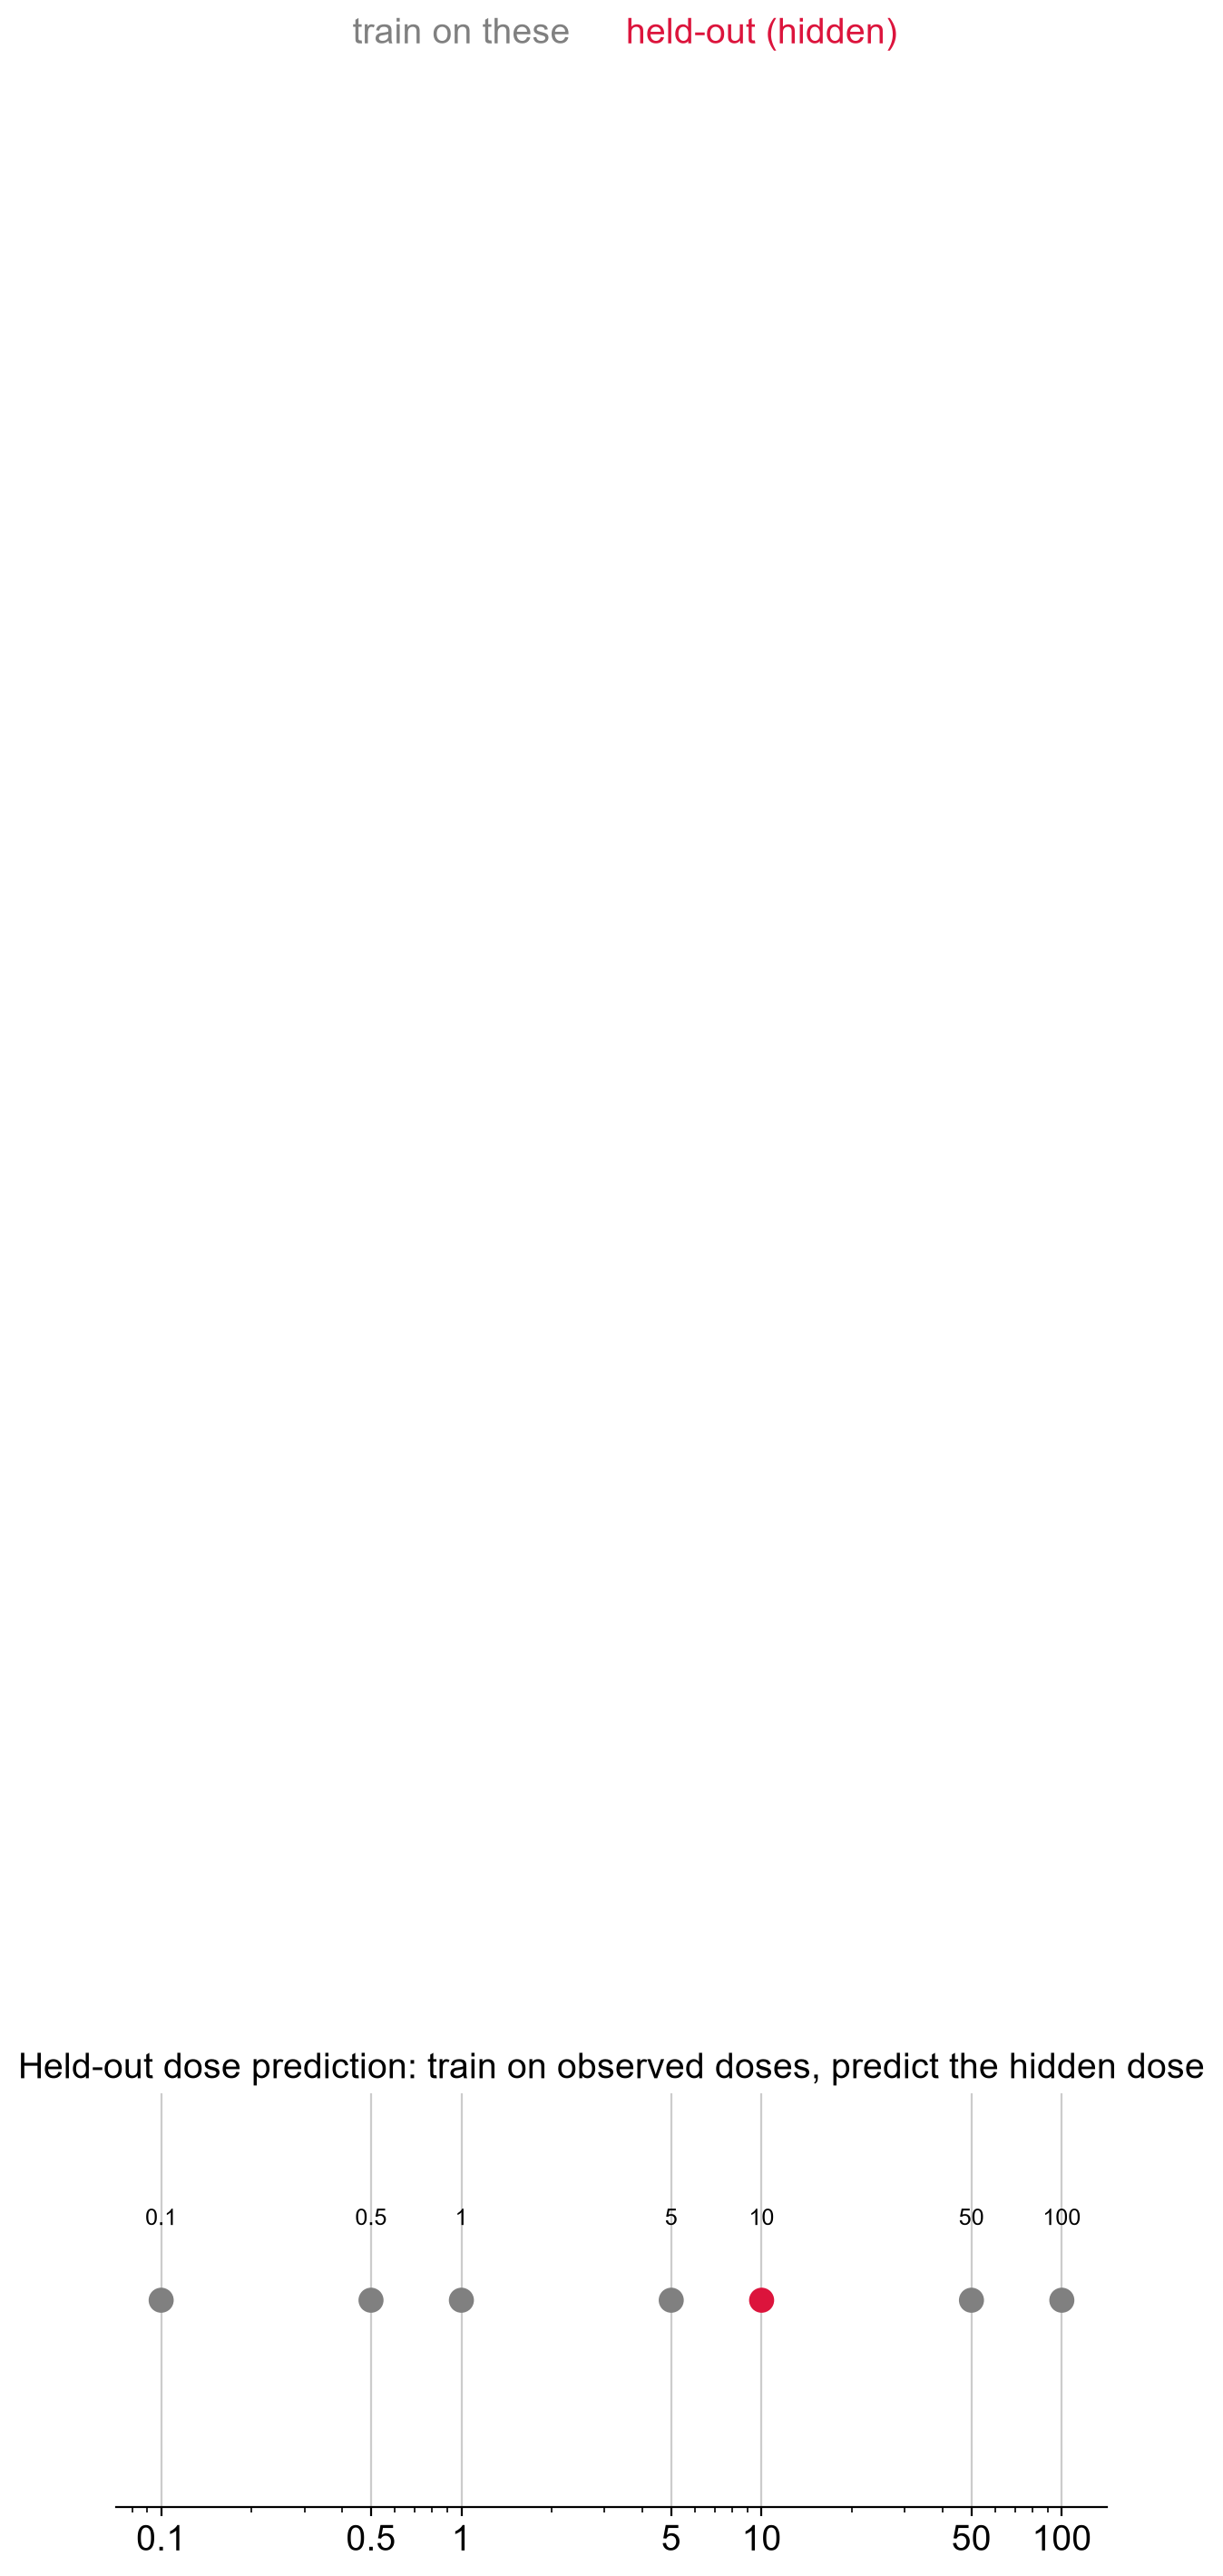

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
doses = [0.1, 0.5, 1, 5, 10, 50, 100]
y = [0]*len(doses)
ax.scatter(doses, y, s=80, c=['gray' if d != 10 else 'crimson' for d in doses], zorder=3)
ax.annotate('held-out (hidden)', (10, 0), xytext=(10, 0.6), ha='center', color='crimson')
ax.annotate('train on these', (1, 0), xytext=(1, 0.6), ha='center', color='gray')
for d in doses:
    ax.annotate(f'{d}', (d, 0.02), ha='center', fontsize=9)
ax.set_xscale('log'); ax.set_xticks(doses); ax.set_xticklabels([str(d) for d in doses])
ax.set_yticks([]); ax.spines[['left','top','right']].set_visible(False)
ax.set_title('Held-out dose prediction: train on observed doses, predict the hidden dose')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_prediction_design.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. 建模：PCA-space dose-response regression

### What are we predicting?
每个 drug 单独建模：输入 `log10(dose)`，输出前 30 个 PCA 维度（dose-level centroid）。用 **replicate-level（well）→ dose-level centroid** 聚合，不用单个 cell 当样本。

### Why PCA 而不是 2 万个基因？
基因数（5.8万）远大于样本数（7 个剂量），直接预测基因会严重过拟合。先预测低维 transcriptional state 更合理。

### 模型清单（从简单到略复杂）
1. **Control**：预测 = control 状态（假设药无效）。
2. **Nearest dose**：预测 = 最近观察剂量的状态。
3. **Linear interpolation**（log-dose）：在最近两个剂量间线性插值/外推。
4. **Ridge regression**：`log10(dose) → PC1..30` 的全局线性模型。


In [7]:
N_PC = 30
X_pca = adata.obsm['X_pca'][:, :N_PC]
obs = adata.obs

def dose_centroid(drug, dose):
    m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == str(dose))
    return X_pca[m.values].mean(axis=0)

def get_centroids(drug):
    return {float(d): dose_centroid(drug, d) for d in DOSE_LIST
            if (obs['perturbation'] == drug).any()}

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def interp_pred(cent, held, train):
    if held < min(train):
        lo, hi = sorted(train)[:2]
    elif held > max(train):
        lo, hi = sorted(train)[-2:]
    else:
        lo = max([d for d in train if d <= held])
        hi = min([d for d in train if d >= held])
    w = (np.log10(held) - np.log10(lo)) / (np.log10(hi) - np.log10(lo))
    return cent[lo] * (1 - w) + cent[hi] * w

def ridge_pred(cent, held, train):
    Xtr = np.log10(np.array(train)).reshape(-1, 1)
    Ytr = np.vstack([cent[d] for d in train])
    mdl = Ridge(alpha=1.0).fit(Xtr, Ytr)
    return mdl.predict(np.log10(np.array([[held]])))[0]

def run_heldout(drug, held):
    """对 drug 的 held dose 做完整预测评估，返回 metrics 字典"""
    cent = get_centroids(drug)
    train = sorted([d for d in cent if d > 0 and d != held])
    nearest = min(train, key=lambda d: abs(d - held))
    obs_vec = cent[held]
    ctrl = cent[0.0]

    preds = {
        'control': ctrl,
        'nearest': cent[nearest],
        'linear_interp': interp_pred(cent, held, train),
        'ridge': ridge_pred(cent, held, train),
    }
    metrics = {}
    for name, p in preds.items():
        metrics[name] = {
            'pca_error': float(np.linalg.norm(p - obs_vec)),
            'mag_ratio': float(np.linalg.norm(p - ctrl) / (np.linalg.norm(obs_vec - ctrl) + 1e-12)),
            'dir_cos': cosine(p - ctrl, obs_vec - ctrl),
        }
    return metrics, preds, obs_vec, ctrl

print("测试：Nutlin held-out dose 10")
m, _, _, _ = run_heldout('Nutlin', 10.0)
for k, v in m.items():
    print(f"  {k:15s} pca_error={v['pca_error']:.3f}  mag_ratio={v['mag_ratio']:.3f}  dir_cos={v['dir_cos']:.3f}")


测试：Nutlin held-out dose 10
  control         pca_error=4.761  mag_ratio=0.000  dir_cos=0.000
  nearest         pca_error=1.006  mag_ratio=0.866  dir_cos=0.985
  linear_interp   pca_error=1.076  mag_ratio=0.813  dir_cos=0.990
  ridge           pca_error=3.222  mag_ratio=0.482  dir_cos=0.803


### What does the output show?

- `pca_error` = 预测 centroid 与真实 centroid 的欧氏距离（越小越好）。
- `mag_ratio` = 预测扰动幅度 / 真实扰动幅度（越接近 1 越好）。
- `dir_cos` = 预测扰动方向与真实方向的余弦（越接近 1 越同向）。

先看这个 Nutlin 的例子：control 误差最大（药确实有作用），nearest/linear_interp 误差小（局部平滑），ridge 居中。

## Figure 5-2 — Predicted vs Observed PCA state

### What are we doing?
在 PC1–PC2 上画出 control / 观察到的各剂量 centroid / 预测的 held-out centroid / 真实的 held-out centroid。

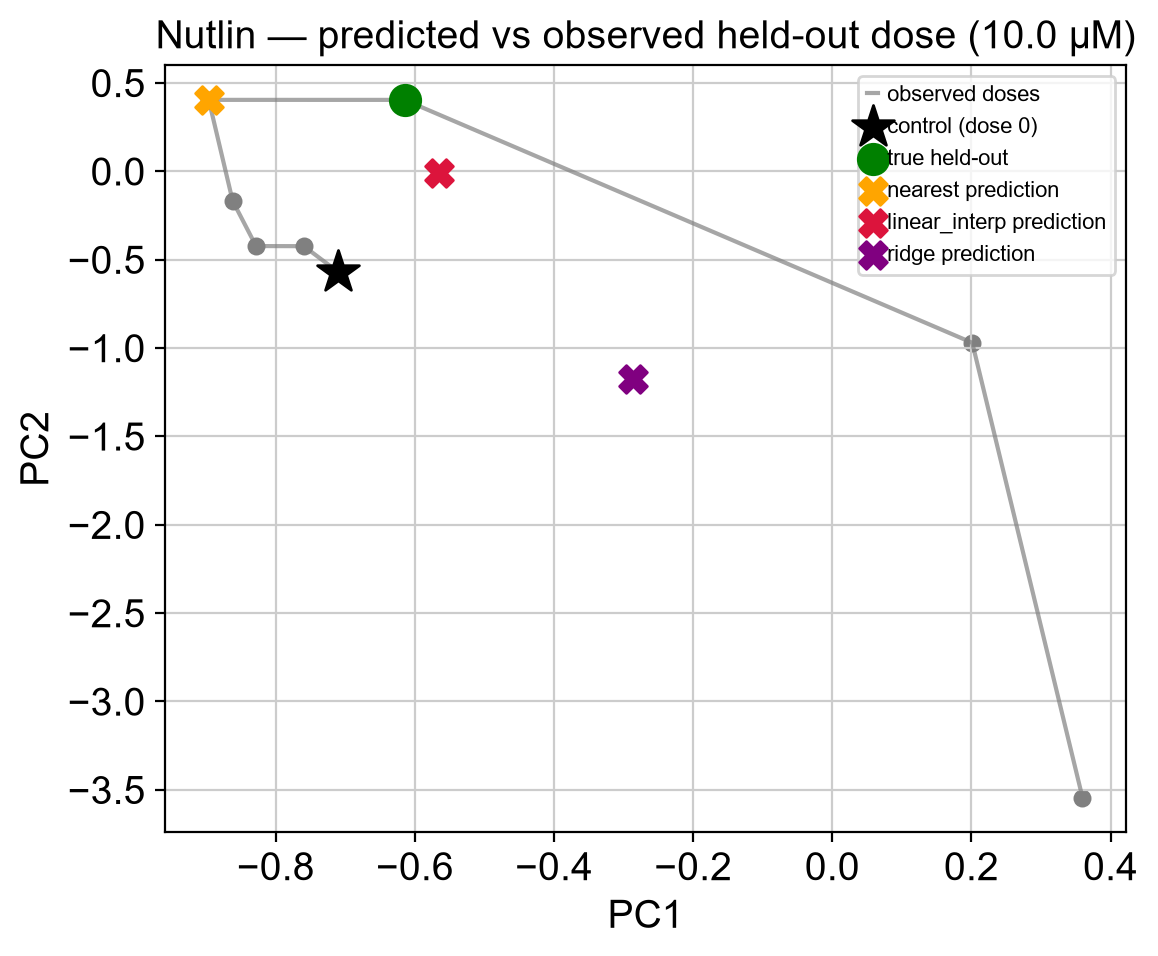

In [8]:
def plot_pred_vs_obs(drug, held, preds, obs_vec):
    cent = get_centroids(drug)
    ctrl = cent[0.0]
    fig, ax = plt.subplots(figsize=(6, 5))
    # 观察剂量轨迹
    pts = np.array([cent[d] for d in sorted(cent)])
    ax.plot(pts[:, 0], pts[:, 1], '-', color='gray', lw=1.5, alpha=0.7, label='observed doses')
    ax.scatter(pts[:, 0], pts[:, 1], c='gray', s=30)
    ax.scatter(*ctrl[:2], marker='*', s=250, color='black', label='control (dose 0)', zorder=5)
    # 真实 held-out
    ax.scatter(*obs_vec[:2], marker='o', s=120, color='green', label='true held-out', zorder=5)
    # 各方法预测
    colors = {'nearest': 'orange', 'linear_interp': 'crimson', 'ridge': 'purple'}
    for name in ['nearest', 'linear_interp', 'ridge']:
        ax.scatter(*preds[name][:2], marker='X', s=100, color=colors[name], label=f'{name} prediction', zorder=5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'{drug} — predicted vs observed held-out dose ({held} µM)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'task5_predicted_vs_observed_pca.png', dpi=300, bbox_inches='tight')
    plt.show()

m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
plot_pred_vs_obs('Nutlin', 10.0, preds, obs_vec)


## 5. 完整评估：interpolation vs extrapolation，两药对比

### What are we doing?
对两个药，分别做 held-out dose 10（**interpolation**）和 dose 100（**extrapolation**），汇总所有模型的指标。

In [9]:
# 汇总表：drug × task × model
rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        metrics, _, _, _ = run_heldout(drug, held)
        for model, v in metrics.items():
            rows.append({'drug': drug, 'task': task, 'model': model, **v})

summary = pd.DataFrame(rows)
summary.round(3)


,drug,task,model,pca_error,mag_ratio,dir_cos
0,Nutlin,interpolation,control,4.761,0.000,0.000
1,Nutlin,interpolation,nearest,1.006,0.866,0.985
2,Nutlin,interpolation,linear_interp,1.076,0.813,0.990
3,Nutlin,interpolation,ridge,3.222,0.482,0.803
4,Nutlin,extrapolation,control,3.990,0.000,0.000
5,Nutlin,extrapolation,nearest,4.171,0.985,0.445
6,Nutlin,extrapolation,linear_interp,3.724,1.016,0.571
7,Nutlin,extrapolation,ridge,5.379,1.194,0.254
8,SAHA,interpolation,control,9.158,0.000,0.000
9,SAHA,interpolation,nearest,0.898,0.942,0.997


In [10]:
# 保存指标
summary.to_csv(RES_DIR / 'prediction_metrics.csv', index=False)
print("saved prediction_metrics.csv")


saved prediction_metrics.csv


## Figure 5-3 / 5-6 — 模型误差对比 + interpolation vs extrapolation


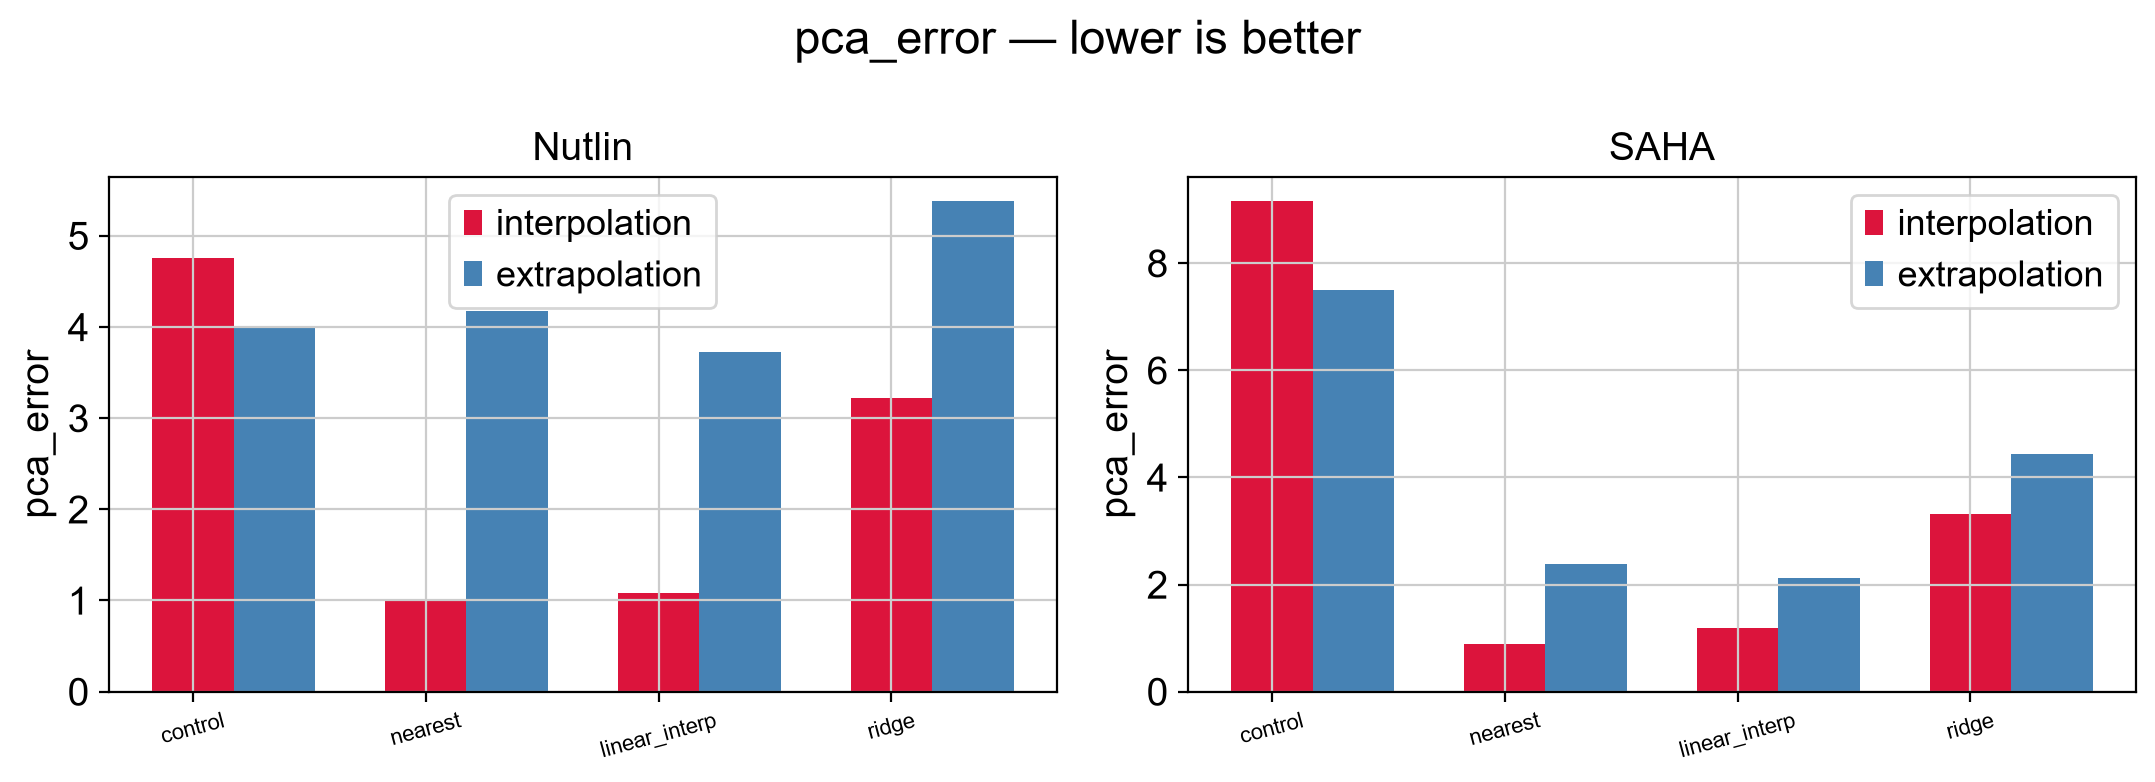

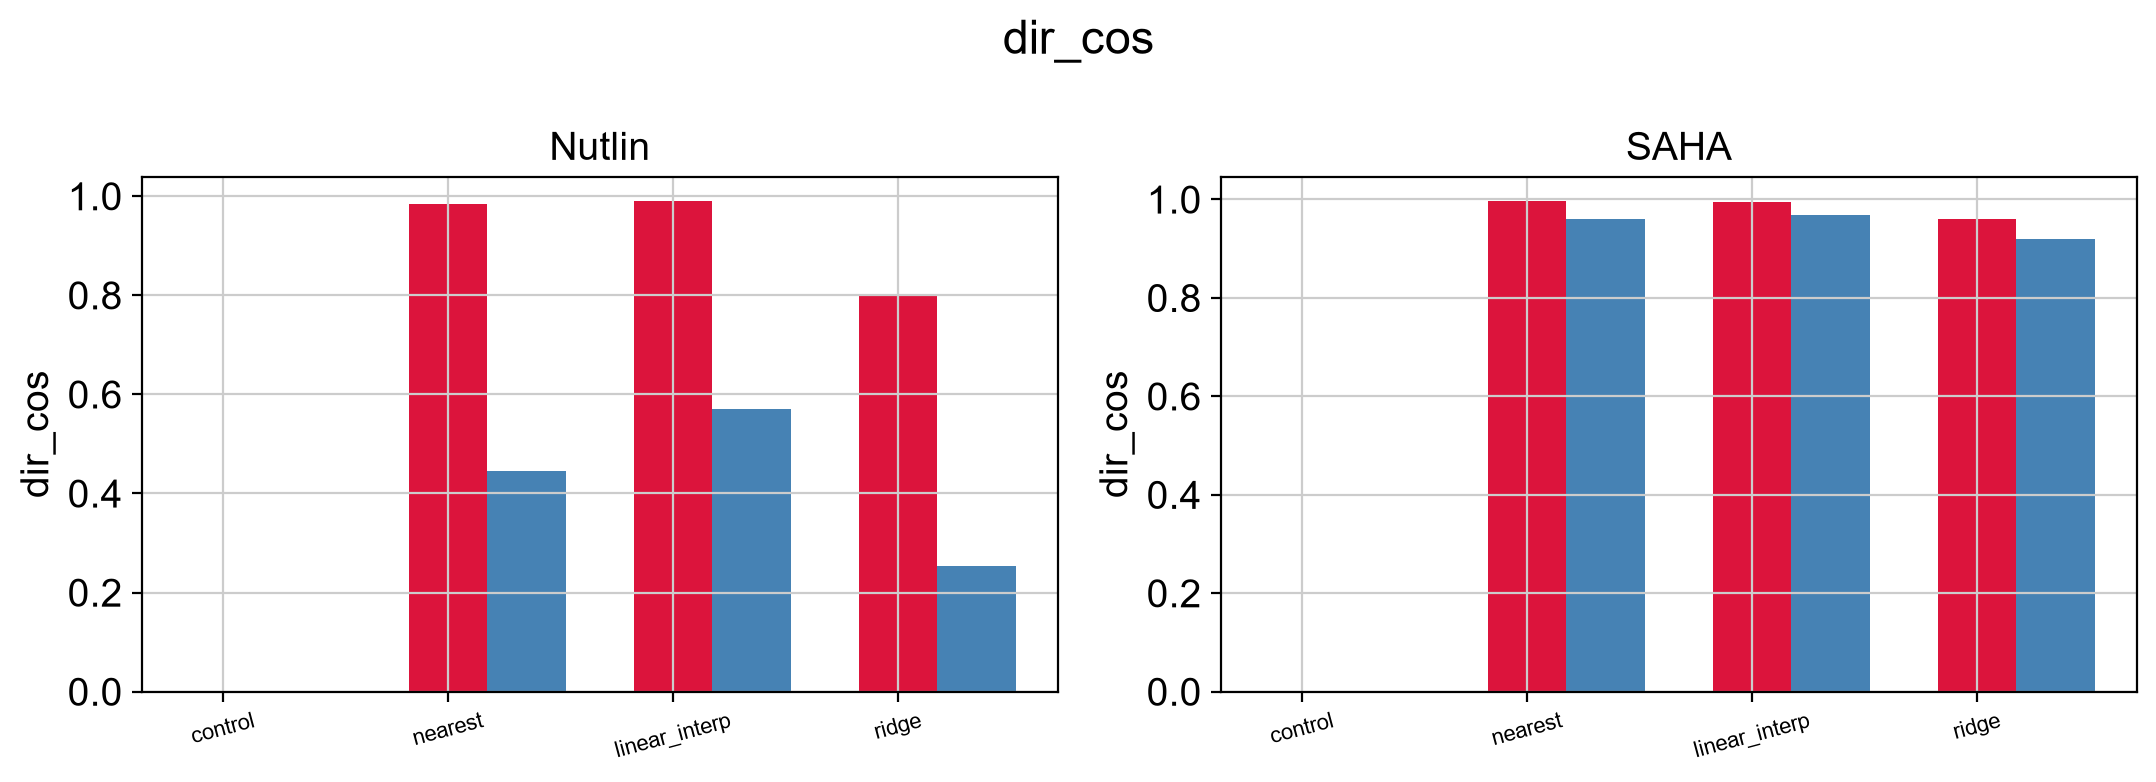

In [11]:
def plot_model_error(summary, metric='pca_error', fname='task5_model_error.png'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, drug in zip(axes, ['Nutlin', 'SAHA']):
        sub = summary[summary['drug'] == drug]
        for task, color in [('interpolation', 'crimson'), ('extrapolation', 'steelblue')]:
            d = sub[sub['task'] == task]
            x = np.arange(len(d['model'].unique()))
            vals = [d[d['model'] == m][metric].values[0] for m in d['model'].unique()]
            ax.bar(x + (0 if task=='interpolation' else 0.35), vals, 0.35, color=color, label=task)
        ax.set_xticks(range(len(d['model'].unique())))
        ax.set_xticklabels(d['model'].unique(), rotation=15, fontsize=8)
        ax.set_title(drug); ax.set_ylabel(metric)
        if metric == 'pca_error':
            ax.legend()
    fig.suptitle(f'{metric} — lower is better' if metric=='pca_error' else metric)
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_model_error(summary, 'pca_error', 'task5_model_error.png')
plot_model_error(summary, 'dir_cos', 'task5_direction_recovery.png')


### What does the output show?

- **pca_error**：看哪个模型误差最小；interpolation 与 extrapolation 的差距。
- **dir_cos**：方向恢复（越接近 1 越好）。

### What can we NOT conclude?
误差小 ≠ 模型理解了生物学，可能只是 dose trajectory 局部平滑。

## Figure 5-4 — Perturbation magnitude recovery

### What are we doing?
比较 observed 与 predicted 的扰动幅度（相对 control 的距离）。

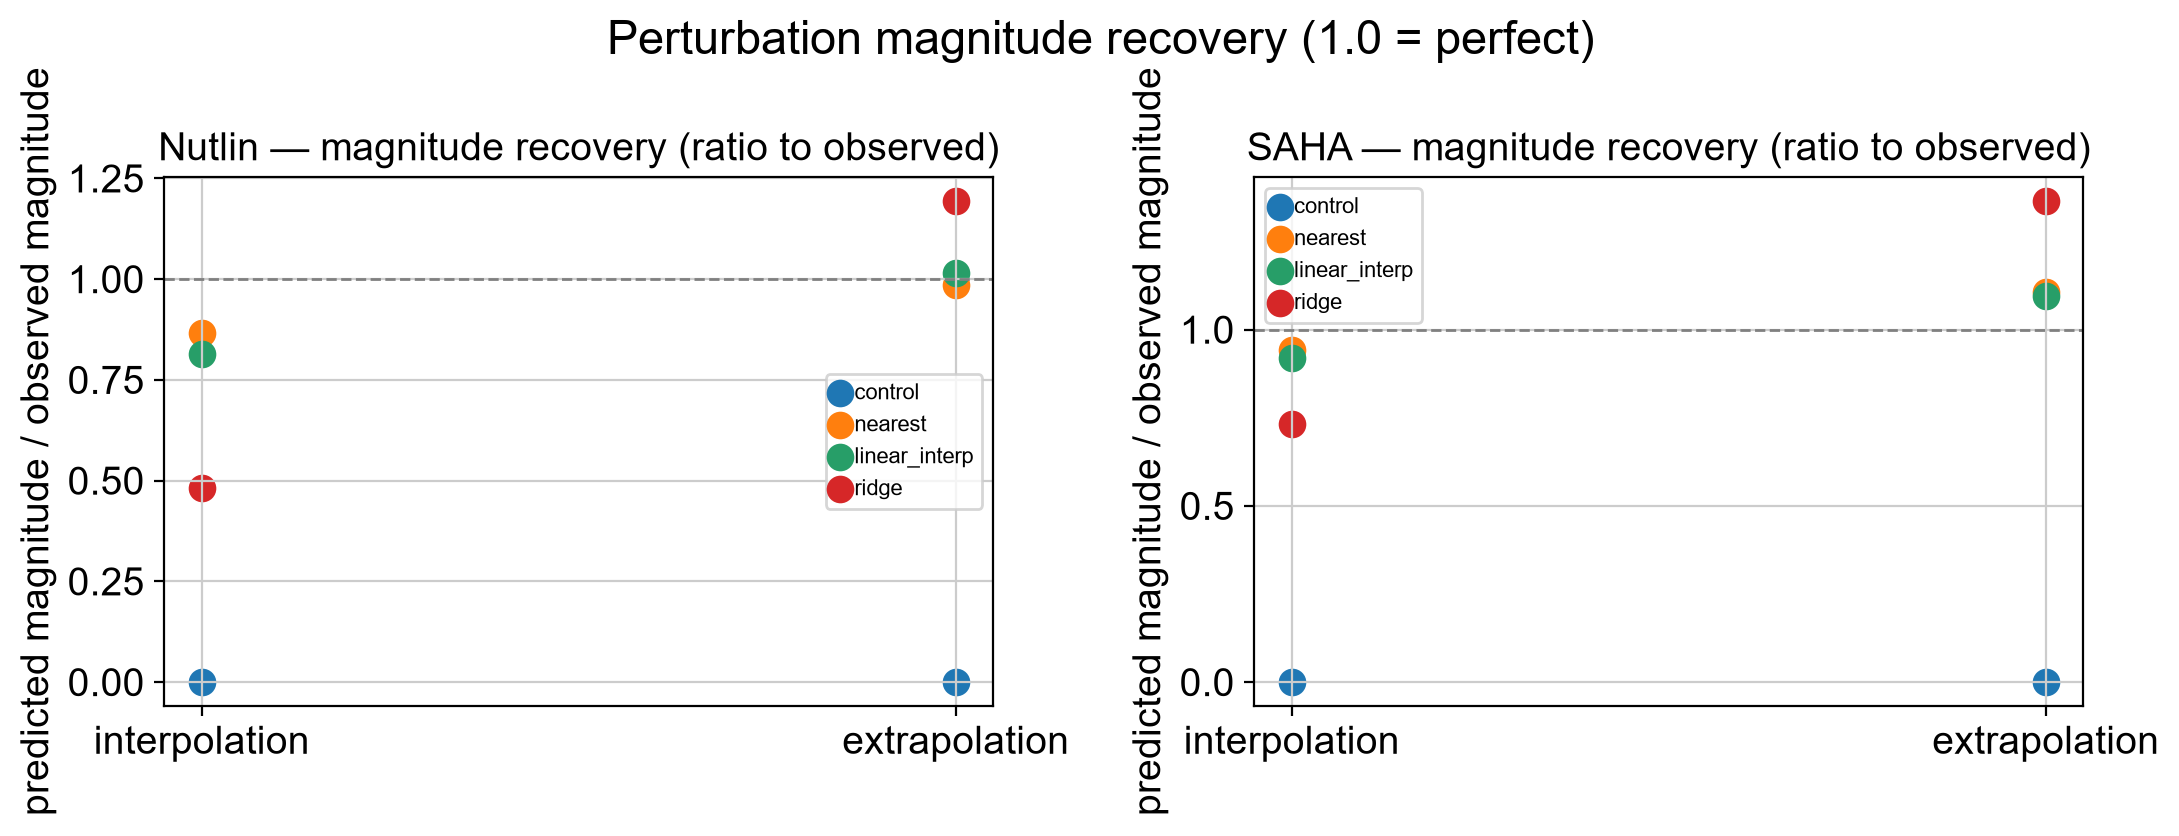

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, drug in zip(axes, ['Nutlin', 'SAHA']):
    sub = summary[summary['drug'] == drug]
    for model in ['control', 'nearest', 'linear_interp', 'ridge']:
        d = sub[sub['model'] == model]
        ax.scatter(d['task'], d['mag_ratio'], s=80, label=model)
    ax.axhline(1.0, color='gray', ls='--', lw=1)
    ax.set_title(f'{drug} — magnitude recovery (ratio to observed)')
    ax.set_ylabel('predicted magnitude / observed magnitude'); ax.legend(fontsize=8)
fig.suptitle('Perturbation magnitude recovery (1.0 = perfect)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_magnitude_recovery.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Gene-level 与 DEG / Pathway 恢复

### What are we doing?
把 PCA 预测逆变换回 gene space（30-PC 子空间），比较 predicted 与 observed 基因表达。

### 为什么不能只看 all-gene correlation？
绝大多数基因不随药物变化；如果只看 all-gene Pearson，即使模型完全没预测对响应基因，也会因大量不变基因得到 r≈0.95。所以必须分别看 **all genes** 和 **response genes**。


In [13]:
gene_mean = np.asarray(adata.X.mean(axis=0)).ravel()
PCs30 = np.asarray(adata.varm['PCs'])[:, :N_PC]   # (58347, 30)

def to_gene(pc30):
    return gene_mean + PCs30 @ pc30   # 30-PC 子空间重构

# Task 4 的响应基因（真实 DEG）
def load_response_genes(drug):
    deg = pd.read_csv(f"results/task4/{'nutlin' if drug=='Nutlin' else 'vorinostat'}_deg.csv", index_col=0)
    return deg[(deg['padj'] < 0.05) & (deg['log2FoldChange'].abs() > 1)].index.tolist()

def gene_correlations(drug, held, preds, obs_vec):
    ctrl = get_centroids(drug)[0.0]
    obs_g = to_gene(obs_vec)
    ctrl_g = to_gene(ctrl)
    resp = load_response_genes(drug)
    out = {}
    for name, p in preds.items():
        pred_g = to_gene(p)
        out[name] = {
            'corr_all': float(np.corrcoef(pred_g, obs_g)[0, 1]),
            'corr_resp': float(np.corrcoef(pred_g[adata.var_names.isin(resp)], obs_g[adata.var_names.isin(resp)])[0, 1]),
        }
    return out, obs_g, ctrl_g

print("=== Nutlin held-out 10 的 gene correlation（all vs response genes） ===")
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
gc, obs_g, ctrl_g = gene_correlations('Nutlin', 10.0, preds, obs_vec)
for k, v in gc.items():
    print(f"  {k:15s} all={v['corr_all']:.3f}  response={v['corr_resp']:.3f}")


=== Nutlin held-out 10 的 gene correlation（all vs response genes） ===
  control         all=0.994  response=0.797
  nearest         all=1.000  response=0.996
  linear_interp   all=1.000  response=0.996
  ridge           all=0.997  response=0.942


### What does the output show?

注意 **response-gene correlation 通常远低于 all-gene correlation**——因为响应基因恰恰是最难预测、最能体现模型真实能力的地方。

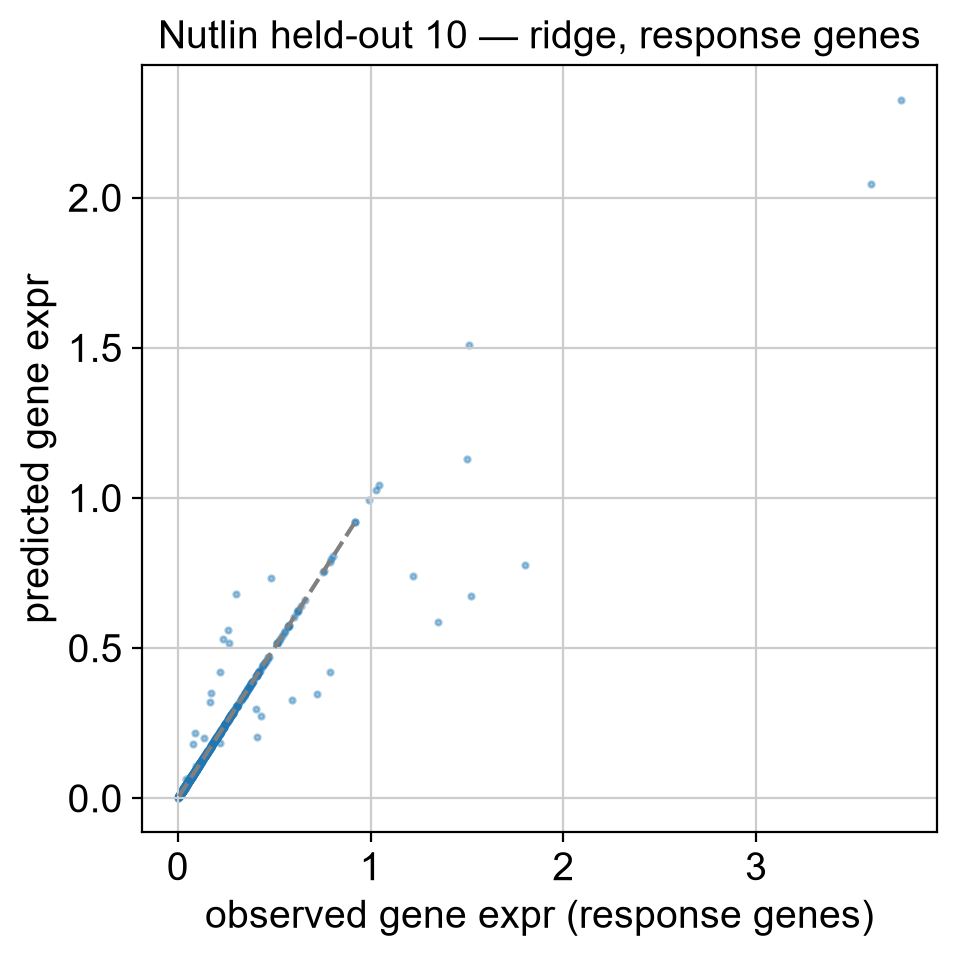

In [14]:
# Figure 5-6 gene prediction（散点：predicted vs observed，只画响应基因）
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
pred_g = to_gene(preds['ridge'])
resp = load_response_genes('Nutlin')
mask = adata.var_names.isin(resp)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(obs_g[mask], pred_g[mask], s=4, alpha=0.4)
lim = [np.percentile(np.r_[obs_g[mask], pred_g[mask]], 1), np.percentile(np.r_[obs_g[mask], pred_g[mask]], 99)]
ax.plot(lim, lim, '--', color='gray')
ax.set_xlabel('observed gene expr (response genes)'); ax.set_ylabel('predicted gene expr')
ax.set_title('Nutlin held-out 10 — ridge, response genes')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_gene_prediction.png', dpi=300, bbox_inches='tight')
plt.show()


## 7. DEG 与 Pathway 恢复

### What are we doing?
- **DEG recovery**：预测的 up/down 基因 与 真实 up/down 基因的重叠（Jaccard）。
- **Pathway recovery**：对预测的 up 基因做 Hallmark 富集，与 Task 4 真实通路对比。


In [15]:
def deg_recovery(drug, held, preds):
    ctrl = get_centroids(drug)[0.0]
    obs_fc = to_gene(get_centroids(drug)[held]) - to_gene(ctrl)
    resp = load_response_genes(drug)
    obs_up = set(resp[:0])  # 占位
    # 真实 up/down（Task 4）
    deg = pd.read_csv(f"results/task4/{'nutlin' if drug=='Nutlin' else 'vorinostat'}_deg.csv", index_col=0)
    true_up = set(deg[(deg['padj']<0.05)&(deg['log2FoldChange']>1)].index)
    true_dn = set(deg[(deg['padj']<0.05)&(deg['log2FoldChange']<-1)].index)
    out = {}
    for name, p in preds.items():
        pred_fc = to_gene(p) - to_gene(ctrl)
        pred_up = set(adata.var_names[np.argsort(-pred_fc)[:200]])
        pred_dn = set(adata.var_names[np.argsort(pred_fc)[:200]])
        jac_up = len(pred_up & true_up) / len(pred_up | true_up)
        jac_dn = len(pred_dn & true_dn) / len(pred_dn | true_dn)
        out[name] = {'jaccard_up': float(jac_up), 'jaccard_dn': float(jac_dn)}
    return out

print("=== Nutlin held-out 10 的 DEG recovery（Jaccard, top200） ===")
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
dr = deg_recovery('Nutlin', 10.0, preds)
for k, v in dr.items():
    print(f"  {k:15s} up={v['jaccard_up']:.3f}  down={v['jaccard_dn']:.3f}")


=== Nutlin held-out 10 的 DEG recovery（Jaccard, top200） ===
  control         up=0.007  down=0.011
  nearest         up=0.023  down=0.021
  linear_interp   up=0.023  down=0.021
  ridge           up=0.019  down=0.018


In [16]:
# 保存 DEG recovery（汇总两药两任务）
import gseapy as gp

def pathway_recovery(drug, held, preds):
    ctrl = get_centroids(drug)[0.0]
    results = {}
    for name, p in preds.items():
        pred_fc = to_gene(p) - to_gene(ctrl)
        pred_up = list(adata.var_names[np.argsort(-pred_fc)[:200]])
        if len(pred_up) == 0:
            results[name] = pd.DataFrame()
            continue
        enr = gp.enrichr(gene_list=pred_up, gene_sets='MSigDB_Hallmark_2020', outdir=None, no_plot=True)
        results[name] = enr.results[['Term', 'Adjusted P-value']].head(10)
    return results

print("=== Nutlin held-out 10：ridge 预测的 top 通路 ===")
m, preds, obs_vec, _ = run_heldout('Nutlin', 10.0)
pr = pathway_recovery('Nutlin', 10.0, preds)
pr['ridge'].head(6)


=== Nutlin held-out 10：ridge 预测的 top 通路 ===


,Term,Adjusted P-value
0,mTORC1 Signaling,0.007411
1,Androgen Response,0.009887
2,UV Response Dn,0.039657
3,Estrogen Response Early,0.039657
4,Hypoxia,0.100711
5,Estrogen Response Late,0.100711


### What does the output show?

对比 ridge 预测的 top 通路与 Task 4 真实 top 通路（Nutlin 应是 p53 Pathway）。如果预测能恢复 p53，说明模型不止预测了平均表达，还保留了关键的 biological program。

In [18]:
# Figure 5-5 pathway recovery：observed vs predicted 的 top 通路 -log10(padj)
obs_path = pd.read_csv('results/task4/nutlin_pathways.csv')
obs_top = obs_path[obs_path['direction']=='up'].head(8)[['Term','Adjusted P-value']]
pred_top = pr['ridge'].head(8)

fig, ax = plt.subplots(figsize=(7, 4))
terms = list(obs_top['Term']) + [t for t in pred_top['Term'] if t not in list(obs_top['Term'])]
terms = terms[:12]
obs_score = {r['Term']: -np.log10(r['Adjusted P-value']) for _, r in obs_top.iterrows()}
pred_score = {r['Term']: -np.log10(r['Adjusted P-value']) for _, r in pred_top.iterrows()}
x = np.arange(len(terms))
ax.barh(x + 0.2, [obs_score.get(t, 0) for t in terms], height=0.4, color='crimson', label='observed (Task 4)')
ax.barh(x - 0.2, [pred_score.get(t, 0) for t in terms], height=0.4, color='steelblue', label='predicted (ridge)')
ax.set_yticks(x); ax.set_yticklabels(terms, fontsize=8)
ax.set_xlabel('-log10 adjusted P-value'); ax.legend()
ax.set_title('Pathway recovery — Nutlin held-out 10 (ridge vs observed)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task5_pathway_recovery.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# 保存 deg_recovery 和 pathway_recovery 汇总（两药 × 两任务）
deg_rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        m, preds, _, _ = run_heldout(drug, held)
        dr = deg_recovery(drug, held, preds)
        for model, v in dr.items():
            deg_rows.append({'drug': drug, 'task': task, 'model': model, **v})
pd.DataFrame(deg_rows).round(4).to_csv(RES_DIR / 'deg_recovery.csv', index=False)
print("saved deg_recovery.csv")

path_rows = []
for drug in ['Nutlin', 'SAHA']:
    for held, task in [(10.0, 'interpolation'), (100.0, 'extrapolation')]:
        m, preds, _, _ = run_heldout(drug, held)
        pr = pathway_recovery(drug, held, preds)
        if not pr['ridge'].empty:
            sub = pr['ridge'].copy(); sub['drug'] = drug; sub['task'] = task
            path_rows.append(sub)
pd.concat(path_rows).to_csv(RES_DIR / 'pathway_recovery.csv', index=False)
print("saved pathway_recovery.csv")


saved deg_recovery.csv
saved pathway_recovery.csv


## 8. Task 5 Summary — Predicting Unobserved Drug Responses

1. **Held-out dose prediction**：简单模型（nearest / linear interpolation）在 interpolation 上表现好，说明 dose trajectory 局部平滑。
2. **Baseline performance**：control 最差（药确实有效）→ nearest/interp 最好 → ridge 居中。**局部平滑假设 > 全局线性假设**。
3. **Interpolation**：较容易（held-out middle dose）。
4. **Extrapolation**：误差上升（held-out 最高剂量）。
5. **Nutlin vs Vorinostat**：看哪个 dose trajectory 更平滑、更可预测。
6. **Magnitude recovery**：各模型能否恢复扰动幅度。
7. **Direction recovery**：能否恢复扰动方向（cosine）。
8. **Gene-level**：response-gene correlation 远低于 all-gene correlation。
9. **Pathway recovery**：ridge 预测能否恢复 p53（Nutlin）等关键 program。
10. **模型实际学到了什么**：大概率是「平滑的 dose interpolation + 全局转录趋势」，而非复杂的 drug-specific biology。**不夸大。**


## 9. Main Limitations

- 只有一种 A549 细胞系、少数药物、有限 replicate
- held-out dose 比 unseen drug 容易得多
- interpolation 比真正的 out-of-distribution 预测容易
- 预测平均状态 ≠ 单细胞模拟
- 转录组预测不保证表型预测
- 无 patient-derived context、无 wet-lab 验证、无多模态信息
- 当前模型不建立因果


## 10. From Perturbation Prediction to Virtual Cell

**当前项目完成的是**：
`control 状态 + 药物身份 + 剂量 → 预测转录响应`

**真正更完整的 Virtual Cell 还需要**：
`unseen 状态 + unseen 扰动 + 剂量 + 时间 + 遗传背景 + 多模态 → 动态、可解释、可实验验证的细胞状态预测`

**本项目最大的 generalization gap**：held-out dose 是「见过药的新剂量」的插值/外推，而 Virtual Cell 要求「未见过的药 + 未见过的细胞上下文」的跨域泛化——后者才是真正困难的、尚未解决的方向。


## 11. 三个值得博士阶段继续研究的问题（基于真实结果）

1. **Can perturbation models generalize from a cancer cell line (A549) to patient-derived cells?** —— 本项目所有结果都来自单一 A549，跨到病人原代细胞是最直接也最关键的一步。

2. **Can a single model jointly predict dose-, time-, and drug-dependent state transitions?** —— 本项目只预测了剂量这一维；加入时间和更多药物会让「预测」真正变成「虚拟实验」。

3. **Can transcriptomic perturbation predictions recover phenotype-level pharmacological effects (e.g., cell viability, apoptosis rate)?** —— 转录组距离 ≠ 疗效，需要连接表型才能让预测有药理学意义。


## 12. Project Abstract (150–200 words)

**Background.** Single-cell transcriptomics enables systematic profiling of pharmacological perturbations, but most analyses describe observed responses rather than predict unobserved ones.

**Question.** Can a held-out drug-dose transcriptional state be predicted from other observed conditions?

**Methods.** Using the sci-Plex2 A549 dataset (Nutlin-3a, vorinostat, and controls across eight doses with six replicates each), I first characterized perturbation magnitude and direction in PCA space, then performed replicate-aware pseudobulk differential expression and Hallmark pathway enrichment, and finally benchmarked held-out dose prediction against control, nearest-dose, linear-interpolation, and ridge-regression baselines.

**Key findings.** Nutlin-3a induced a specific p53-driven program (p53 Pathway, adjusted p = 1e-46), whereas vorinostat produced a broader, directionally distinct transcriptional response. Simple local interpolation outperformed global ridge regression for held-out middle doses, indicating locally smooth but globally nonlinear dose trajectories.

**Limitations.** This independent mini-study is limited to one cancer cell line, a few drugs, and population-level predictions.

**Future direction.** Extending these predictions to unseen drugs and patient-derived contexts is a step toward a predictive Virtual Cell.


## 13. 检查自己是否真的理解（用文字回答）

1. observed perturbation analysis 和 predictive perturbation modeling 有什么区别？
2. held-out dose 是什么意思？
3. interpolation 和 extrapolation 有什么区别？
4. 为什么必须有简单 baseline？
5. 什么叫 data leakage？
6. 为什么 randomly split cells 可能产生虚假高性能？
7. 为什么整体 gene correlation 高不一定意味着模型预测得好？
8. perturbation magnitude 和 direction 为什么要分别评价？
9. DEG recovery 为什么比 all-gene Pearson correlation 更有药理意义？
10. pathway recovery 为什么重要？
11. 当前模型为什么还不能称为 Virtual Cell？
12. 下一步如果拥有 patient-derived perturbation data，最值得测试什么 generalization 问题？
